# Dataset Zoo: Every Built-in Dataset

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/salihyesil59/CosmoFit/blob/main/examples/01-getting-started/dataset_zoo.ipynb)

CosmoFit bundles **21 datasets**. This notebook loads each one on
its own against a *fixed* fiducial cosmology — Planck-2018-like flat
ΛCDM, fit to none of them — so you can see what each actually
measures before deciding what to combine.

| Probe | Keys |
|---|---|
| **Expansion** | `cc` |
| **BAO** | `desi`, `sdss_bao`, `sdss_fsbao`, `bao_lowz`, `eboss_elg`, `eboss_elg_fs`, `eboss_lya` |
| **Supernovae** | `pantheon`, `des_sn5yr`, `union3` |
| **CMB** | `planck`, `planck_lite`, `planck_lensing`, `planck_lowe`, `act_lensing` |
| **Growth** | `fsigma8`, `s8` |
| **Priors** | `h0`, `omega_b`, `tau` |

Three of them are **not Gaussian** — they ship a likelihood surface
rather than a mean and a covariance — and one needs a Boltzmann
code. Both cases are covered below.

It ends with the full list of **which datasets must not be combined**,
which is longer than it looks: sixteen pairs, every one a case of the
same sky, the same supernovae, or the same number counted twice.

**Running this:** no MCMC, a couple of minutes.

## Setup

In [ ]:
import sys

# On Colab, install the released package and nothing else.
#
# This used to clone the repository and install it editable,
# which needed a `sys.path` fix afterwards: pip runs in a
# subprocess, so the already-running kernel never saw the .pth
# file it wrote, and `import CosmoFit` could resolve to the bare
# checkout directory instead -- same name, and /content is on
# sys.path. A normal install goes to site-packages, which is
# already there, so all of that goes away.

if "google.colab" in sys.modules:
    !pip install -q "cosmofit[cmb]"
else:
    print("Not running in Colab -- assuming CosmoFit is already "
          'installed (pip install "cosmofit[cmb]").')


In [2]:
import warnings

import numpy as np
import matplotlib.pyplot as plt

from CosmoFit import Fitter, LCDM
from CosmoFit.stats.fitter import CONFLICTING_DATASETS, DATASET_REGISTRY
from CosmoFit.data.loader import dataset_reference

plt.rcParams["figure.dpi"] = 110

print(f"{len(DATASET_REGISTRY)} datasets registered")

21 datasets registered


A fixed fiducial point, and a helper that builds a single-dataset
`Fitter` there without fitting anything.

In [3]:
FIDUCIAL = dict(
    H0=67.4, Omega_m=0.315, Omega_b=0.0493, rd=147.09,
    sigma8=0.811, n_s=0.965, ln1e10As=3.044, tau_reio=0.0544,
    A_planck=1.0, MB=-19.253,
)


def look(*keys, free_params=("H0", "Omega_m"), **kwargs):
    """A Fitter on `keys` at the fiducial point. Nothing is fit."""

    return Fitter(
        model=LCDM,
        datasets=list(keys),
        free_params=list(free_params),
        initial=FIDUCIAL,
        **kwargs,
    )

## 1. All of them at once

`chi2` here is the *fiducial* chi-squared — no parameter has been
adjusted to any of these — so it is a rough goodness-of-fit for
Planck's ΛCDM, not a best fit.

In [4]:
def has_camb():
    try:
        import camb  # noqa: F401
        return True
    except ImportError:
        return False


rows = []

for key in DATASET_REGISTRY:

    if key == "planck_lite" and not has_camb():
        rows.append((key, None, None, "needs the 'cmb' extra"))
        continue

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = look(key)
        rows.append((key, fit.n_data, fit.chi2(), ""))

print(f"{'dataset':>15s} {'n_data':>7s} {'chi2':>10s} {'chi2/n':>8s}")
for key, n, chi2, note in rows:
    if n is None:
        print(f"{key:>15s} {'-':>7s} {'-':>10s} {'-':>8s}   {note}")
    else:
        print(f"{key:>15s} {n:7d} {chi2:10.2f} {chi2 / n:8.2f}")

        dataset  n_data       chi2   chi2/n
             cc      32      13.34     0.42
           desi      12      20.78     1.73
       sdss_bao       8       6.60     0.83
     sdss_fsbao      12      16.46     1.37
      eboss_elg       1       0.36     0.36
   eboss_elg_fs       3       2.86     0.95
      eboss_lya       2       4.91     2.46
       bao_lowz       2       0.88     0.44
       pantheon    1624    1457.50     0.90
      des_sn5yr    1820    1632.45     0.90
         union3      22      26.41     1.20
         planck       3       0.71     0.24
    planck_lite     613     584.28     0.95
 planck_lensing       9       8.80     0.98
    planck_lowe      28     396.10    14.15
    act_lensing      10      14.09     1.41
        fsigma8      22      17.43     0.79
             s8       1      10.25    10.25
             h0       1      29.41    29.41
        omega_b       1       0.15     0.15
            tau       1       0.00     0.00


Two rows need reading carefully.

**`planck_lowe`** shows `chi2 ≈ 396` for 28 points, which is not a
bad fit. It is a *tabulated* likelihood — a lookup of released
log-probabilities — so its zero point is whatever Planck's table
uses, and only **differences** in it mean anything. The same is true
of the three eBOSS tables below. Compare such a dataset against
itself at other parameters, never against a chi-squared-per-point of
1.

In [5]:
for tau in (0.02, 0.0544, 0.09):
    fit = Fitter(model=LCDM, datasets=["planck_lowe"],
                 free_params=["tau_reio"], initial={**FIDUCIAL, "tau_reio": tau})
    print(f"  tau = {tau:.4f}   chi2 = {fit.chi2():8.2f}")

print("\nThe absolute value is meaningless; the shape is the measurement.")

  tau = 0.0200   chi2 =   404.94


  tau = 0.0544   chi2 =   396.10


  tau = 0.0900   chi2 =   415.40
The absolute value is meaningless; the shape is the measurement.


## 2. Expansion: cosmic chronometers

The only dataset here that measures `H(z)` directly — from the
differential ageing of passively evolving galaxies, with no distance
ladder and no sound horizon involved. 32 points, and its covariance
carries Moresco et al.'s systematic terms rather than being
diagonal.

Favale, Gomez-Valent & Migliaccio (2023), MNRAS 523, 3406, arXiv:2301.09591


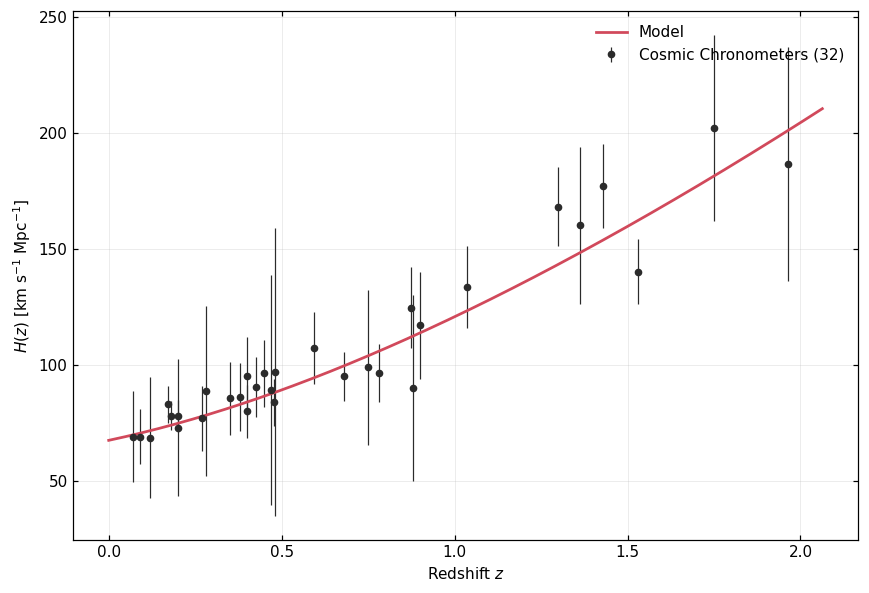

In [6]:
fit_cc = look("cc")
print(dataset_reference("cc"))
fit_cc.plots.hz();

## 3. BAO

Five independent compilations, plus two full-shape analyses. All of
them measure distances **in units of the sound horizon** `r_d`, so
`r_d` is either fit as a nuisance parameter or computed from the
physical densities (`Fitter(compute_rd=True)`).

In [7]:
for key in ("desi", "sdss_bao", "sdss_fsbao", "bao_lowz"):
    fit = look(key)
    print(f"{key:>12s}  n={fit.n_data:3d}  chi2={fit.chi2():7.2f}   "
          f"{dataset_reference(key)[:64]}")

        desi  n= 12  chi2=  20.78   DESI Collaboration (2024), JCAP 02 (2025) 021, arXiv:2404.03002
    sdss_bao  n=  8  chi2=   6.60   Alam et al. (2017), arXiv:1607.03155 (BOSS DR12, z=0.38/0.51); e
  sdss_fsbao  n= 12  chi2=  16.46   SDSS BAO + full-shape consensus -- eBOSS Collaboration / Alam et
    bao_lowz  n=  2  chi2=   0.88   Beutler et al. (2011), MNRAS 416, 3017, arXiv:1106.3366 (6dFGS, 


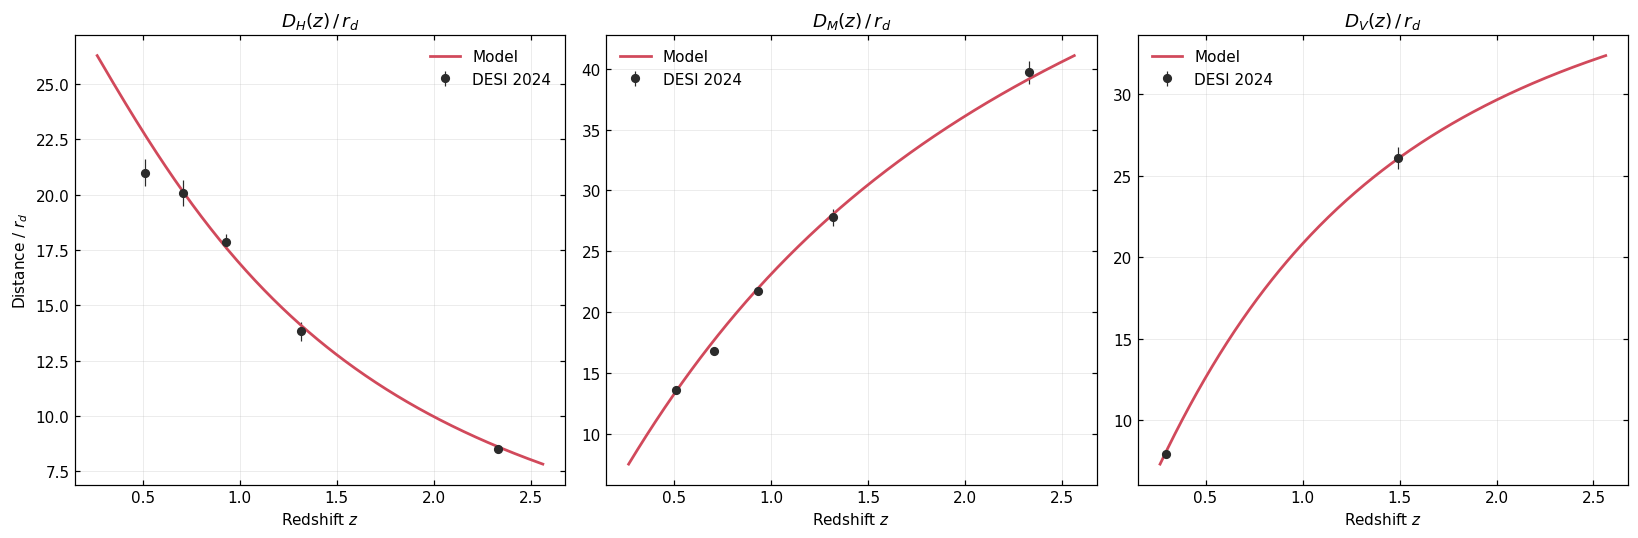

In [8]:
look("desi").plots.bao_distances();

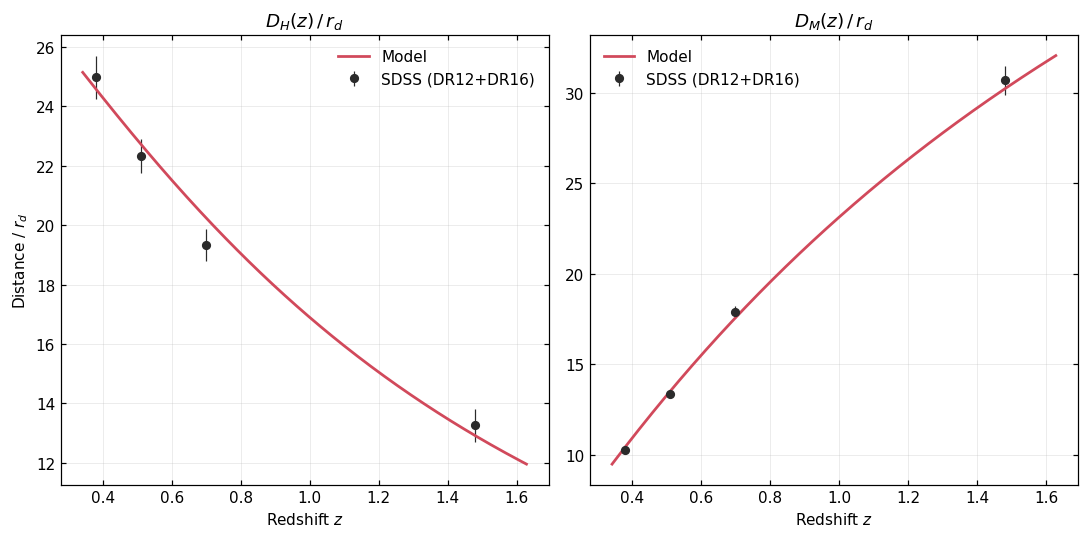

In [9]:
look("sdss_bao").plots.sdss_bao_distances();

### DESI has two releases

`dataset_kwargs` picks the version. They are the same survey, so
they are alternatives, not additions.

In [10]:
for version in ("desi2024", "desi2025"):
    fit = look("desi", **{"dataset_kwargs": {"desi": {"version": version}}})
    print(f"  {version}: n={fit.n_data:3d}  chi2={fit.chi2():6.2f}   "
          f"{dataset_reference('desi', version)[:58]}")

  desi2024: n= 12  chi2= 20.78   DESI Collaboration (2024), JCAP 02 (2025) 021, arXiv:2404.
  desi2025: n= 13  chi2= 28.97   DESI Collaboration (2025), arXiv:2503.14738 (DESI DR2 Resu


### The three that are not Gaussian

eBOSS DR16 released two of its BAO measurements as likelihood
**surfaces**, because a Gaussian misrepresents them — and the ELG
full-shape analysis as a 3-D grid over `(D_M/r_d, D_H/r_d, f σ8)`.

CosmoFit carries the tables and interpolates the **log**-probability
on them. That is the difference between reproducing the published
constraint and reproducing a symmetric approximation to it.

In [11]:
for key in ("eboss_elg", "eboss_lya", "eboss_elg_fs"):
    fit = look(key, free_params=("H0", "Omega_m", "sigma8"))
    print(f"{key:>14s}  n={fit.n_data}  chi2={fit.chi2():7.3f}  "
          f"(tabulated: zero point is arbitrary)")

     eboss_elg  n=1  chi2=  0.355  (tabulated: zero point is arbitrary)
     eboss_lya  n=2  chi2=  4.910  (tabulated: zero point is arbitrary)
  eboss_elg_fs  n=3  chi2=  2.860  (tabulated: zero point is arbitrary)


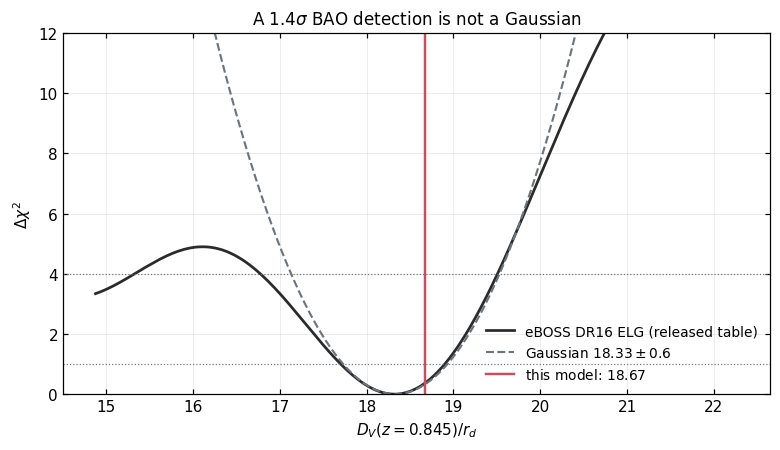

In [12]:
look("eboss_elg").plots.eboss_surface("eboss_elg");

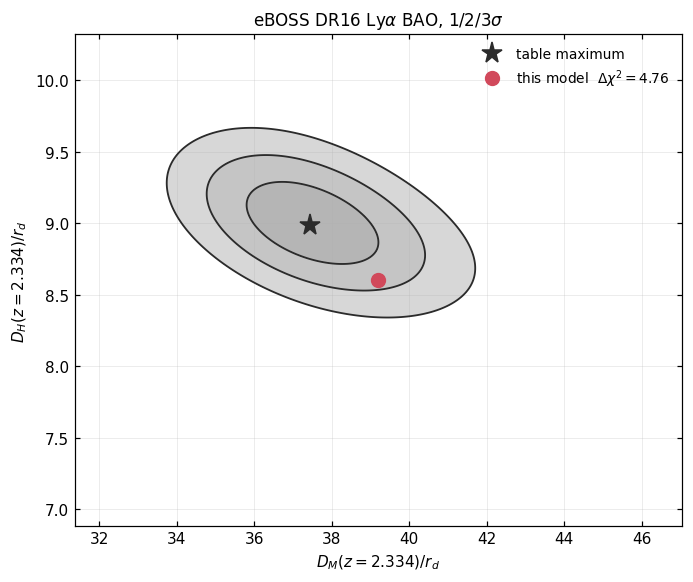

In [13]:
look("eboss_lya").plots.eboss_surface("eboss_lya");

Left: the released 1-D curve against the Gaussian its published
summary would imply — they part company in the low tail, which is
the half that decides whether a low expansion rate at z ≈ 0.85 is
excluded. Right: the Lyman-α 2-D surface as Δχ² contours, which is
measurably not an ellipse.

## 4. Supernovae

Three compilations. Each measures a distance modulus, so each needs
an absolute magnitude — which Pantheon+ and DES-SN5YR **marginalize
analytically** by default. Freeing `MB` alongside them adds a
parameter the likelihood cannot see.

In [14]:
for key in ("pantheon", "des_sn5yr", "union3"):
    fit = look(key)
    print(f"{key:>12s}  n={fit.n_data:5d}  chi2={fit.chi2():8.2f}   "
          f"{dataset_reference(key)[:56]}")

    pantheon  n= 1624  chi2= 1457.50   Brout et al. (2022), ApJ 938, 110, arXiv:2202.04077
   des_sn5yr  n= 1820  chi2= 1632.45   Sanchez et al. (2024), arXiv:2406.05046; DES Collaborati
      union3  n=   22  chi2=   26.41   Rubin et al. (2023), arXiv:2311.12098 (Union3 / UNITY1.5


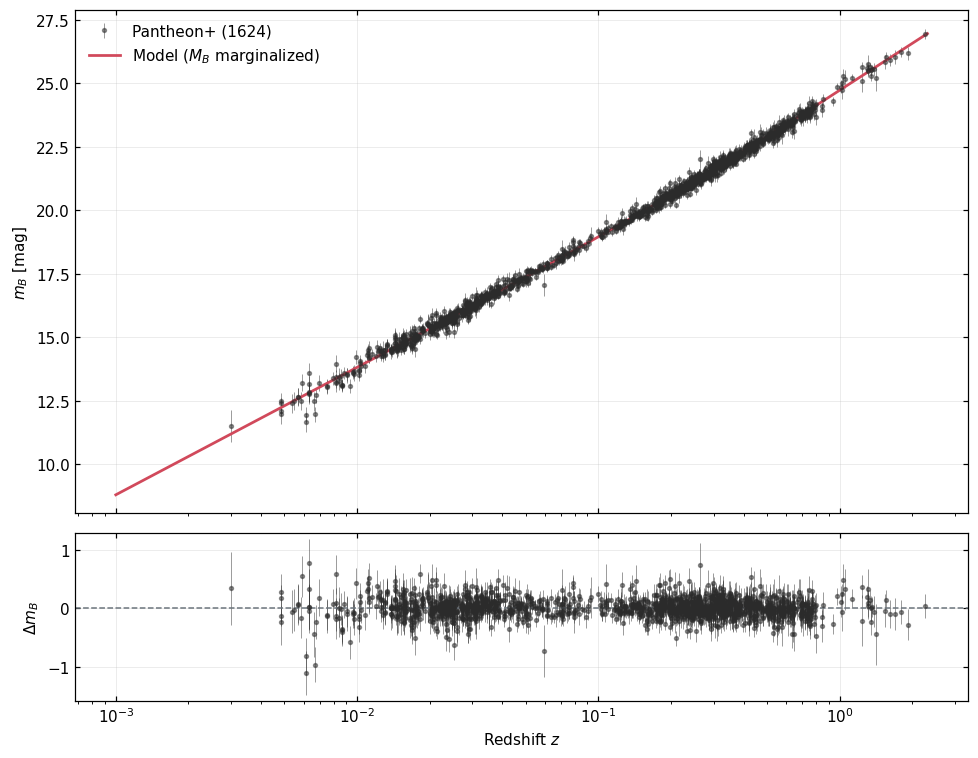

In [15]:
look("pantheon").plots.hubble_diagram();

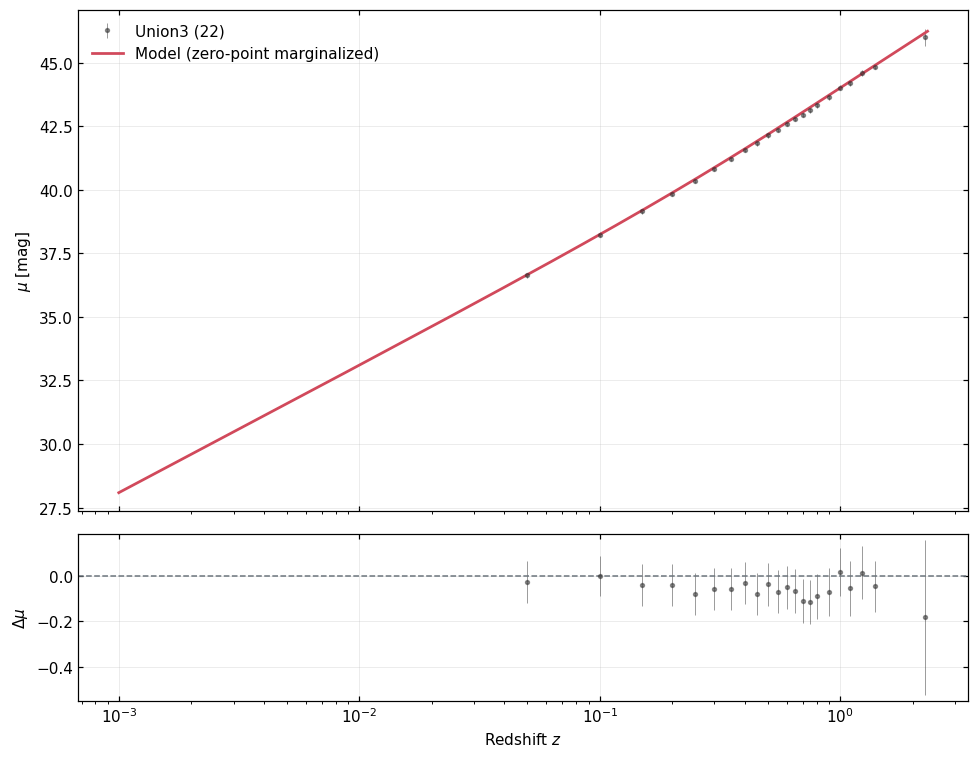

In [16]:
look("union3").plots.union3_hubble_diagram();

## 5. CMB

Five entries, from a three-number summary to the full spectrum.

| key | what it is | cost |
|---|---|---|
| `planck` | compressed distance priors: `R`, `l_A`, `omega_b h²` | free |
| `planck_lite` | 615 TT/TE/EE bandpowers, computed from scratch | needs CAMB |
| `planck_lensing` | the lensing power spectrum, 9 bandpowers | free |
| `planck_lowe` | the low-ℓ EE table — where `tau` is actually measured | needs CAMB |
| `act_lensing` | ACT DR6 lensing, an independent instrument | free |

The compressed priors are the cheap route and are what most
dark-energy papers use. They are also **blind to the neutrino
mass** by construction — `z_star` is a fitting formula calibrated at
Σm_ν = 0.06 eV — so a fit that frees `m_nu` against them is
measuring nothing, and `Fitter` says so.

In [17]:
for key in ("planck", "planck_lensing", "act_lensing"):
    fit = look(key)
    print(f"{key:>16s}  n={fit.n_data:3d}  chi2={fit.chi2():7.2f}   "
          f"{dataset_reference(key)[:52]}")

if has_camb():
    for key in ("planck_lowe", "planck_lite"):
        fit = look(key, free_params=("H0", "Omega_m", "ln1e10As", "tau_reio"))
        print(f"{key:>16s}  n={fit.n_data:3d}  chi2={fit.chi2():7.2f}")
else:
    print("\n  planck_lowe / planck_lite skipped: pip install 'cosmofit[cmb]'")

          planck  n=  3  chi2=   0.71   Chen, Huang & Wang (2019), JCAP 02 (2019) 028, arXiv


  planck_lensing  n=  9  chi2=   8.80   Planck Collaboration (2020), A&A 641, A8, arXiv:1807


     act_lensing  n= 10  chi2=  14.09   Madhavacheril et al. (ACT Collaboration, 2024), ApJ 


     planck_lowe  n= 28  chi2= 396.10


     planck_lite  n=613  chi2= 584.28


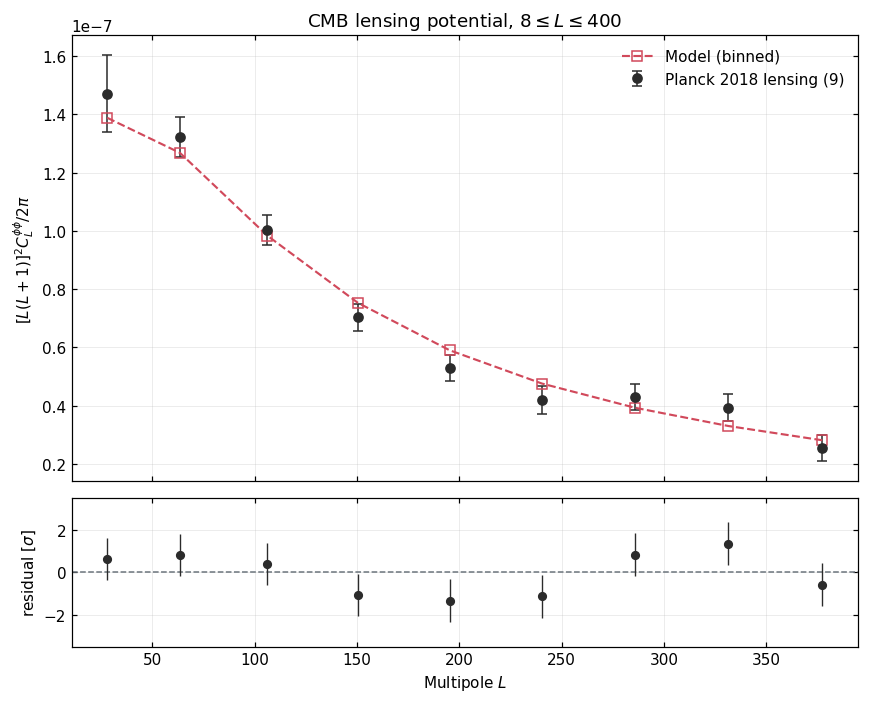

In [18]:
look("planck_lensing").plots.cmb_lensing();

## 6. Growth of structure

The only datasets that see *how gravity clusters matter*, rather
than how far away things are. Two models with identical `E(z)` can
differ here — which is the whole reason modified-gravity fits need
them.

   fsigma8  n= 22  chi2=  17.43   Sagredo, Nesseris & Sapone (2018), Phys. Rev. D 98, 0835
        s8  n=  1  chi2=  10.25   Asgari et al. (2021), A&A 645, A104, arXiv:2007.15633


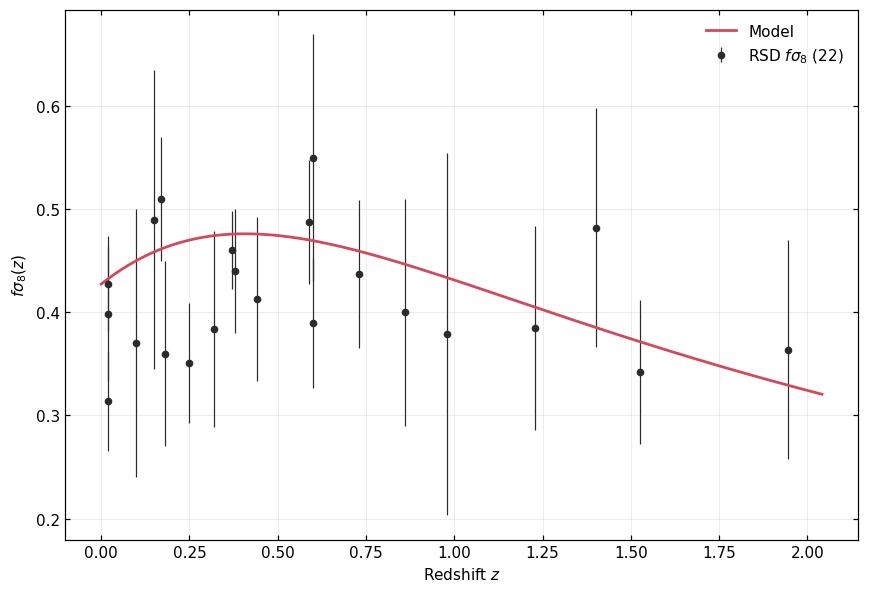

In [19]:
for key in ("fsigma8", "s8"):
    fit = look(key, free_params=("H0", "Omega_m", "sigma8"))
    print(f"{key:>10s}  n={fit.n_data:3d}  chi2={fit.chi2():7.2f}   "
          f"{dataset_reference(key)[:56]}")

look("fsigma8", free_params=("H0", "Omega_m", "sigma8")).plots.growth();

## 7. Single-number priors

Three Gaussian priors, each a one-line summary of a much larger
analysis. Cheap, and each is a *choice* about what external
information to import.

- `h0` — the SH0ES distance-ladder `H0`. Adding it is what creates
  the H₀ tension inside a fit, rather than resolving it.
- `omega_b` — the BBN deuterium constraint on `omega_b h²`, which is
  what makes `r_d` computable without the CMB.
- `tau` — the Gaussian shorthand for `planck_lowe`. Never both.

In [20]:
for key in ("h0", "omega_b", "tau"):
    fit = look(key, free_params=("H0", "Omega_m"))
    print(f"{key:>10s}  n={fit.n_data}  chi2={fit.chi2():7.2f}   "
          f"{dataset_reference(key)[:56]}")

print("\nThe h0 chi2 above is the H0 tension, in one number:")
print("the fiducial Planck H0 against the distance ladder.")

        h0  n=1  chi2=  29.41   Riess et al. (2022), ApJ 934, L7, arXiv:2112.04510
   omega_b  n=1  chi2=   0.15   Schoeneberg (2024), JCAP 06 (2024) 006, arXiv:2401.15054
       tau  n=1  chi2=   0.00   Planck Collaboration (2020), A&A 641, A6, arXiv:1807.062
The h0 chi2 above is the H0 tension, in one number:
the fiducial Planck H0 against the distance ladder.


## 8. What not to combine

More datasets is not better. Sixteen pairs here are **not**
independent measurements — they are the same sky, the same
supernovae, or the same number twice — and combining them multiplies
a likelihood by part of itself. That tightens and biases the
posterior with no visible symptom.

`Fitter` carries the list and warns.

In [21]:
print(f"{len(CONFLICTING_DATASETS)} conflicting pairs:\n")

for (first, second), reason in CONFLICTING_DATASETS.items():
    print(f"  {first:>14s} + {second:<14s} {reason.strip().splitlines()[0]}")

16 conflicting pairs:
            desi + sdss_bao       DESI covers much of the same sky and the same structure BOSS/eBOSS did; they are not independent.
            desi + sdss_fsbao     DESI covers much of the same sky and the same structure BOSS/eBOSS did; they are not independent.
        sdss_bao + sdss_fsbao     The same BOSS/eBOSS galaxies analysed two ways -- the BAO peak alone, and the full anisotropic shape with the growth rate. `sdss_fsbao` contains these BAO measurements.
      sdss_fsbao + fsigma8        The `fsigma8` compilation includes BOSS and eBOSS growth measurements, which `sdss_fsbao` measures again -- this time jointly with the geometry.
        sdss_bao + fsigma8        The `fsigma8` compilation includes BOSS and eBOSS growth measurements from the same galaxies `sdss_bao`'s BAO comes from, and the two are correlated (0.19 to 0.64 within a redshift bin in the released covariance). Use `sdss_fsbao`, which measures both jointly.
            desi + eboss_lya      DES

In [22]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    look("desi", "sdss_bao")

for warning in caught:
    print(f"{warning.category.__name__}:\n{warning.message}")

Datasets 'desi' and 'sdss_bao' should not be combined: DESI covers much of the same sky and the same structure BOSS/eBOSS did; they are not independent. Treating them as independent double-counts that data, which understates the uncertainties and can bias the result. Use one of the two.


The rule of thumb: **one BAO compilation, one supernova
compilation, one version of each CMB likelihood** per fit.
Everything else composes freely.

## 9. A valid combination

Cosmic chronometers + DESI DR2 + DES-SN5YR + the compressed Planck
priors + BBN, with `r_d` computed from the physical densities rather
than fit — five mutually independent probes.

In [23]:
fit = Fitter(
    model=LCDM,
    datasets=["cc", "desi", "des_sn5yr", "planck", "omega_b"],
    dataset_kwargs={"desi": {"version": "desi2025"}},
    free_params=["H0", "Omega_m", "Omega_b"],
    initial=FIDUCIAL,
    compute_rd=True,
)

print(f"{fit.n_data} data points from {len(fit.likelihoods)} likelihoods\n")
for likelihood in fit.likelihoods:
    print(f"  {likelihood}")

best = fit.best_fit(restarts=3, seed=0)
print()
for name, value in zip(fit.free_params, best.x):
    print(f"  {name:9s} = {value: .4f}")
print(f"\n  chi2 = {best.fun:.2f} / {fit.n_data} points")
print(f"  derived r_d = {fit.cosmology.sound_horizon.rd_computed():.2f} Mpc")

1869 data points from 5 likelihoods
  CCLikelihood(name='CC', n_data=32)
  DESILikelihood(name='DESI', n_data=13)
  DESSN5YRLikelihood(name='DES-SN5YR', n_data=1820)
  PlanckLikelihood(name='Planck', n_data=3)
  OmegaBLikelihood(name='BBN', n_data=1)


  H0        =  68.3006
  Omega_m   =  0.3021
  Omega_b   =  0.0482
  chi2 = 1664.16 / 1869 points
  derived r_d = 147.54 Mpc


## Next steps

- [`quickstart.ipynb`](quickstart.ipynb) — the shortest path to a
  real MCMC posterior.
- [`../02-models/model_zoo_comparison.ipynb`](../02-models/model_zoo_comparison.ipynb)
  — the same data against six models.
- [`../02-models/modified_gravity_growth.ipynb`](../02-models/modified_gravity_growth.ipynb)
  — `fsigma8`/`s8` used for what they are for.
- [`../05-case-studies/s8_tension_cmb.ipynb`](../05-case-studies/s8_tension_cmb.ipynb)
  — `planck_lite` in earnest: the full spectrum from scratch.
- [`../05-case-studies/dark_energy_evidence_audit.ipynb`](../05-case-studies/dark_energy_evidence_audit.ipynb)
  — how much a conclusion depends on *which* of these you picked.